# Lab 5 - Logistic Regression and Support Vector Machine
The goal of this lab is to deepen you understanding of using logistic regression and SVM for classification tasks.

In [71]:
%pip install idx2numpy

Note: you may need to restart the kernel to use updated packages.


In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import idx2numpy

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score
from torchvision import datasets, transforms
from collections import Counter

## Task 1: Predict Breast Cancer using Logistic Regression 

### Step 1: Data Loading and Preprocessing

In [73]:
df = pd.read_csv("breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Step 2: Remove NaN

In [74]:
df = df.drop('Unnamed: 32', axis=1)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Step 3: Correlation Visualization

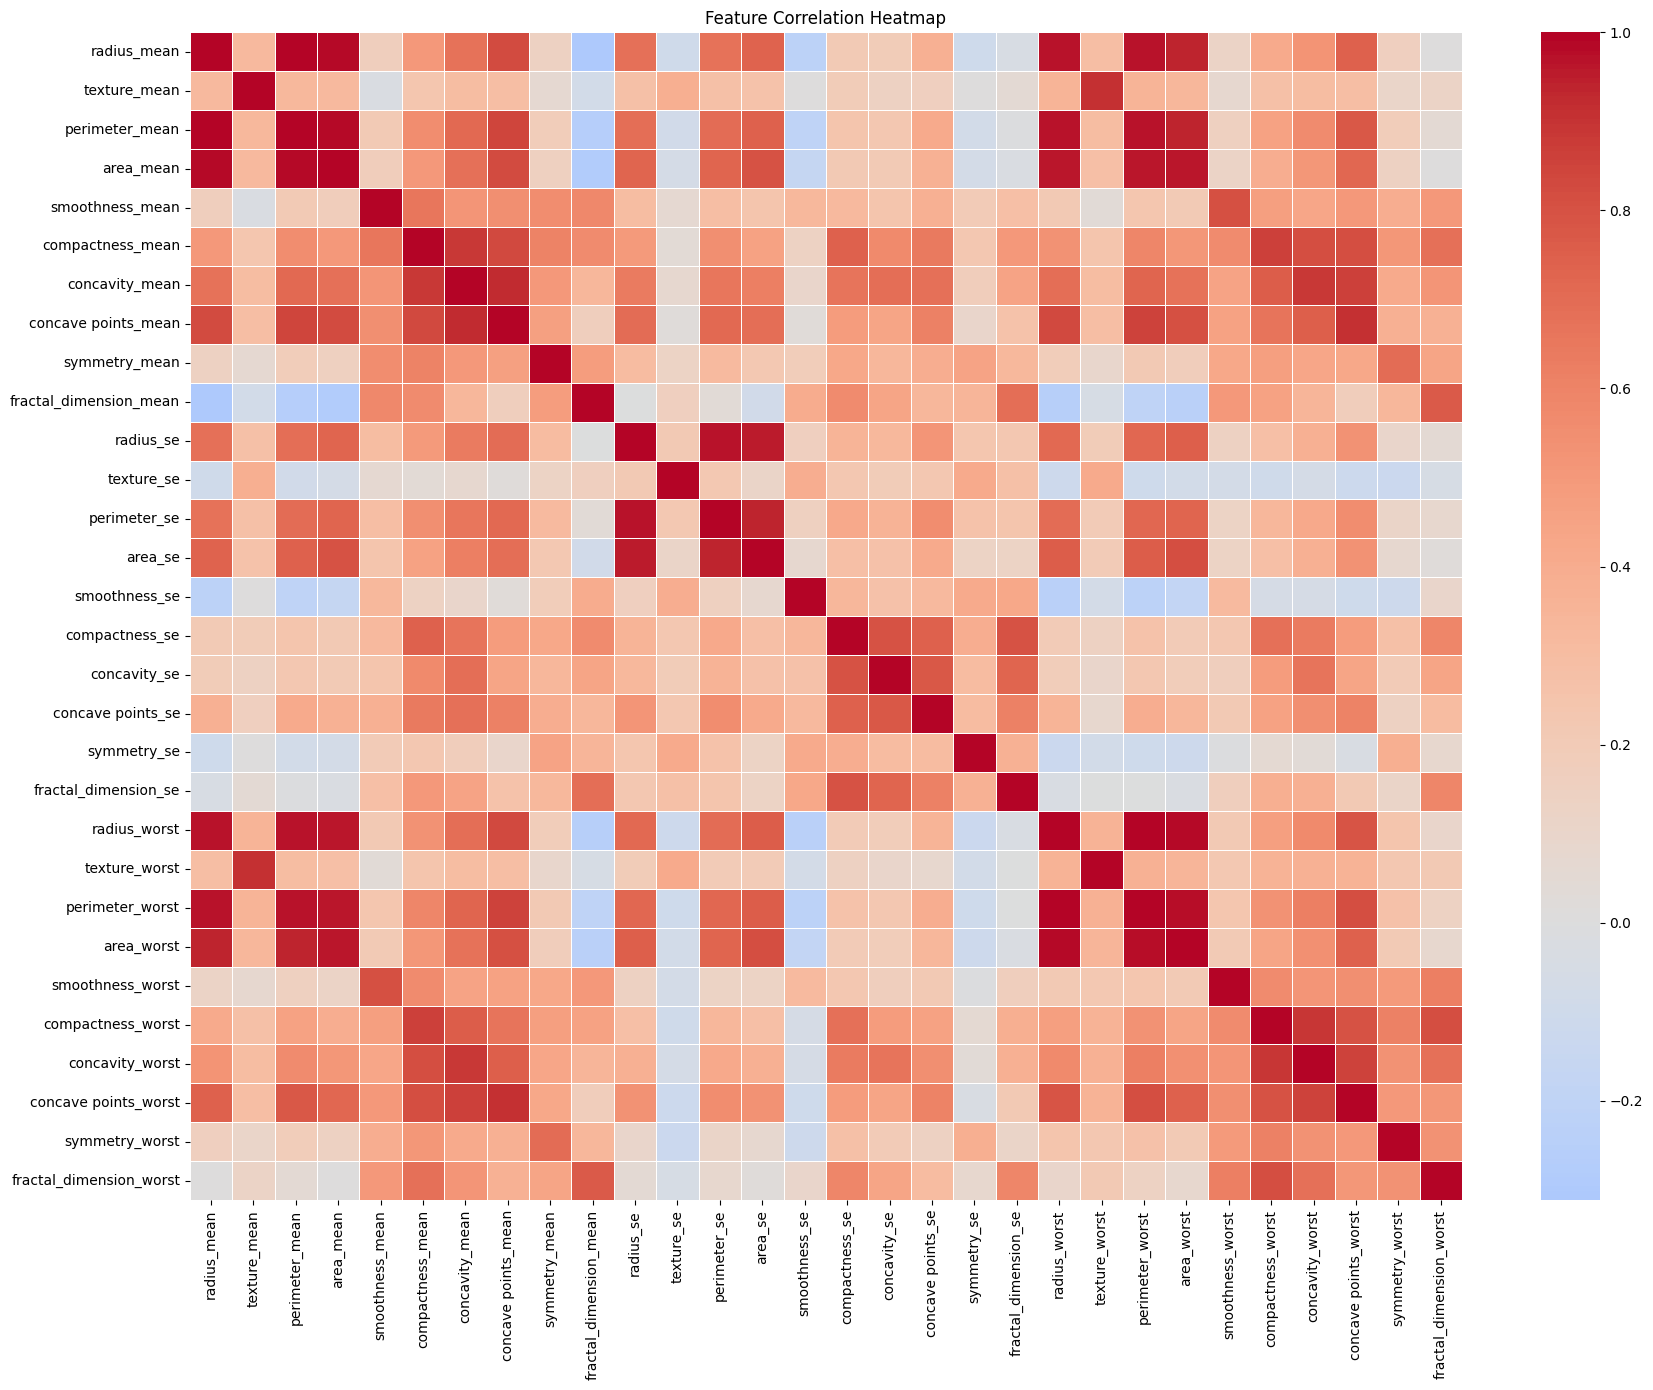

In [93]:
features = df.drop(columns=['id', 'diagnosis'])
corr_matrix = features.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# Identify highly correlated feature pairs (|r| > 0.9)
threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated feature pairs:")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {f1} <-> {f2}: r = {r:.4f}")

Highly correlated feature pairs:
  radius_mean <-> perimeter_mean: r = 0.9979
  radius_worst <-> perimeter_worst: r = 0.9937
  radius_mean <-> area_mean: r = 0.9874
  perimeter_mean <-> area_mean: r = 0.9865
  radius_worst <-> area_worst: r = 0.9840
  perimeter_worst <-> area_worst: r = 0.9776
  radius_se <-> perimeter_se: r = 0.9728
  perimeter_mean <-> perimeter_worst: r = 0.9704
  radius_mean <-> radius_worst: r = 0.9695
  perimeter_mean <-> radius_worst: r = 0.9695
  radius_mean <-> perimeter_worst: r = 0.9651
  area_mean <-> radius_worst: r = 0.9627
  area_mean <-> area_worst: r = 0.9592
  area_mean <-> perimeter_worst: r = 0.9591
  radius_se <-> area_se: r = 0.9518
  perimeter_mean <-> area_worst: r = 0.9415
  radius_mean <-> area_worst: r = 0.9411
  perimeter_se <-> area_se: r = 0.9377
  concavity_mean <-> concave points_mean: r = 0.9214
  texture_mean <-> texture_worst: r = 0.9120
  concave points_mean <-> concave points_worst: r = 0.9102


### Step 4: Feature Selection — Drop Redundant Correlated Features

In [ ]:
# Drop highly correlated features
cols_to_drop = [
    'perimeter_mean', 'area_mean',          # correlated with radius_mean
    'perimeter_worst', 'area_worst',         # correlated with radius_worst
    'perimeter_se', 'area_se',               # correlated with radius_se
    'concavity_mean',                        # correlated with concave points_mean
    'texture_worst',                         # correlated with texture_mean
]

### Step 5: Standardize Features and Train-Test Split

In [ ]:
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split: 80% train, 20% test, random_state=42, shuffle=True
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=True
)

### Step 6: Train Logistic Regression

In [ ]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Step 7: Model Performance Analysis

**The model has excellent performance:**


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9824561403508771

Confusion Matrix:
[[70  1]
 [ 1 42]]


## Task 2: Digit Recognition using SVM 

In [ ]:
# Define the transformation to convert images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the MNIST dataset with the specified transformation
mnist_pytorch = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Create a DataLoader to load the dataset in batches
train_loader_pytorch = torch.utils.data.DataLoader(mnist_pytorch, batch_size=1, shuffle=False)

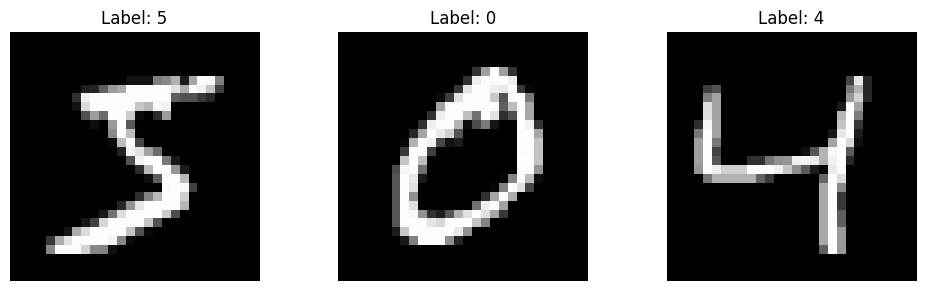

In [ ]:
# Plot the first three images
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for idx, (image, label) in enumerate(train_loader_pytorch):
    if idx == 3:  # Stop after displaying the first three images
        break
    axes[idx].imshow(image.squeeze().numpy(), cmap='gray')
    axes[idx].set_title(f'Label: {label.item()}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Load MNIST dataset. Path subject to change
X_train = './data/MNIST/raw/train-images-idx3-ubyte'
y_train = './data/MNIST/raw/train-labels-idx1-ubyte'
X_test = './data/MNIST/raw/t10k-images-idx3-ubyte'
y_test = './data/MNIST/raw/t10k-labels-idx1-ubyte'

X_train = idx2numpy.convert_from_file(X_train)
y_train = idx2numpy.convert_from_file(y_train)
X_test = idx2numpy.convert_from_file(X_test)
y_test = idx2numpy.convert_from_file(y_test)

# Vectorization the images
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape)

(60000, 784)


In [84]:
linear_model = SVC(kernel='linear')
# Fit SVM
linear_model.fit(X_train, y_train)

# Prediction using SVM
y_pred = linear_model.predict(X_test)

In [85]:
# Evaluate linear SVM
linear_acc = accuracy_score(y_test, y_pred)
print(f"Linear SVM Accuracy: {linear_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Linear SVM Accuracy: 0.9404

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.99      0.98      1135
           2       0.93      0.94      0.93      1032
           3       0.91      0.94      0.92      1010
           4       0.94      0.96      0.95       982
           5       0.91      0.90      0.91       892
           6       0.96      0.95      0.95       958
           7       0.95      0.93      0.94      1028
           8       0.94      0.90      0.92       974
           9       0.95      0.91      0.93      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [86]:
non_linear_model = SVC(kernel='rbf') # Alternative choice: kernel='poly'
# Fit SVM
non_linear_model.fit(X_train, y_train)

# Prediction using SVM
y_pred = non_linear_model.predict(X_test)

In [87]:
# Evaluate non-linear (RBF) SVM
rbf_acc = accuracy_score(y_test, y_pred)
print(f"RBF SVM Accuracy: {rbf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

RBF SVM Accuracy: 0.9792

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Step 5: Model Comparison

| Model | Accuracy |
|---|---|
| Linear SVM | 94.04% |
| RBF SVM | 97.92% |

**Preferred RBF SVM.** The RBF kernel captures non-linear decision boundaries in the high-dimensional pixel space, which better separates digit classes that are not linearly separable.

### Discussion: OvO for 10-class SVM

SVM uses One-vs-One for multi-class classification. For 10 classes, the number of binary classifiers needed is:

$$\binom{10}{2} = \frac{10 \times 9}{2} = 45$$

So 45 binary classifiers are required.


## Task 3: k-Nearest Neighbor Algorithm for Breast Cancer Prediction 

In [90]:
# Step 1: Implement k-NN from scratch using Euclidean distance
def knn_predict(X_train, y_train, X_test, k):
    """
    k-Nearest Neighbor classifier using Euclidean distance.
    
    Input:
        X_train: np.ndarray of shape (n_train, n_features) - training features
        y_train: np.ndarray of shape (n_train,) - training labels
        X_test:  np.ndarray of shape (n_test, n_features) - test features
        k:       int - number of nearest neighbors
    
    Output:
        predictions: np.ndarray of shape (n_test,) - predicted labels
    """
    predictions = []
    for test_point in X_test:
        # Euclidean distance to all training points
        distances = np.sqrt(np.sum((X_train - test_point) ** 2, axis=1))
        # Indices of k nearest neighbors
        k_indices = np.argsort(distances)[:k]
        # Majority vote
        k_labels = y_train[k_indices]
        counts = Counter(k_labels)
        predictions.append(counts.most_common(1)[0][0])
    return np.array(predictions)

In [91]:
# Step 2: Load preprocessed features from Task 1
X_bc = df_clean.drop(columns=['diagnosis']).values
y_bc = df_clean['diagnosis'].values

# Scale
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

# Split 80/20
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42, shuffle=True
)

# Step 3: k-NN with k=5
y_pred_k5 = knn_predict(X_train_bc, y_train_bc, X_test_bc, k=5)
print(f"k=5 Accuracy: {accuracy_score(y_test_bc, y_pred_k5):.4f}")

k=5 Accuracy: 0.9561


k=3: Accuracy = 0.9298
k=5: Accuracy = 0.9561
k=7: Accuracy = 0.9474
k=9: Accuracy = 0.9474


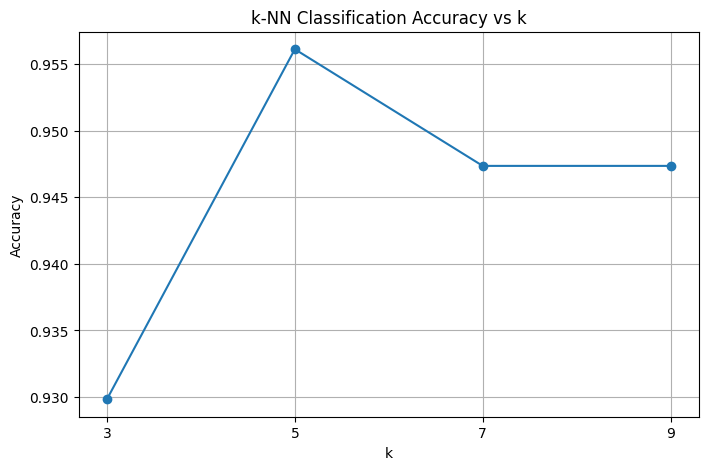


Best k = 5 with accuracy = 0.9561


In [92]:
# Step 4: Evaluate k-NN for k = 3, 5, 7, 9
k_values = [3, 5, 7, 9]
accuracies = []
for k in k_values:
    y_pred_k = knn_predict(X_train_bc, y_train_bc, X_test_bc, k=k)
    acc = accuracy_score(y_test_bc, y_pred_k)
    accuracies.append(acc)
    print(f"k={k}: Accuracy = {acc:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k-NN Classification Accuracy vs k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"\nBest k = {best_k} with accuracy = {max(accuracies):.4f}")